# Uniform Train/Val/Test split for all models
- Global distribution of profiles is unbalanced
- Although all data was cross-calibrated, Profiles from the same cruise may not be independent (more similar to each other)
- distribution of profiles to clusters (target-variable) is also unbalanced and train/test sets should have equal representations of each cluster

**Aim**:
- Training and test data should both have Profiles from equal geographical distributions (Laitude, Longitude, MarineRegion)
- Cruise ids should not overlap between training and test data (and between cross-validation folds)
    - Problem with large cruises, like one int he Southern Ocean - split into two sub-cruises (earlier and later half) for better distribution
- Validation data: use of cross-validation, assign validation-block ids to Profiles

**Output of this notebook:**
- table with Profile_id -> data_type matching (data_type is either train or test, training data has additional value in column CV_fold, specifying the CV block)


In [68]:
import pandas as pd
data = pd.read_pickle('../Data/Environmental_data_depth_resolved_subset.pkl')
data['Profile_id'] = data['Profile_id'].astype(str)
data['datetime'] = pd.to_datetime(data['datetime'])

# merge clusters with mapping to see which profiles are in which cluster and data_type
clusters = pd.read_pickle('../Data/Profile_id_to_clusters.pkl')
data = clusters.merge(data, on="Profile_id", how='left')
#data.info()

# only keep columns "Profile_id, Latitude, Longitude, datetime, Cruise" and drop duplicates
data = data[["Profile_id", "Latitude", "Longitude", "datetime", "Cruise", "MarineRegion","cluster"]].drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5613 entries, 0 to 224480
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Profile_id    5613 non-null   object        
 1   Latitude      5613 non-null   float64       
 2   Longitude     5613 non-null   float64       
 3   datetime      5613 non-null   datetime64[ns]
 4   Cruise        5613 non-null   object        
 5   MarineRegion  5613 non-null   object        
 6   cluster       5613 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), object(3)
memory usage: 328.9+ KB


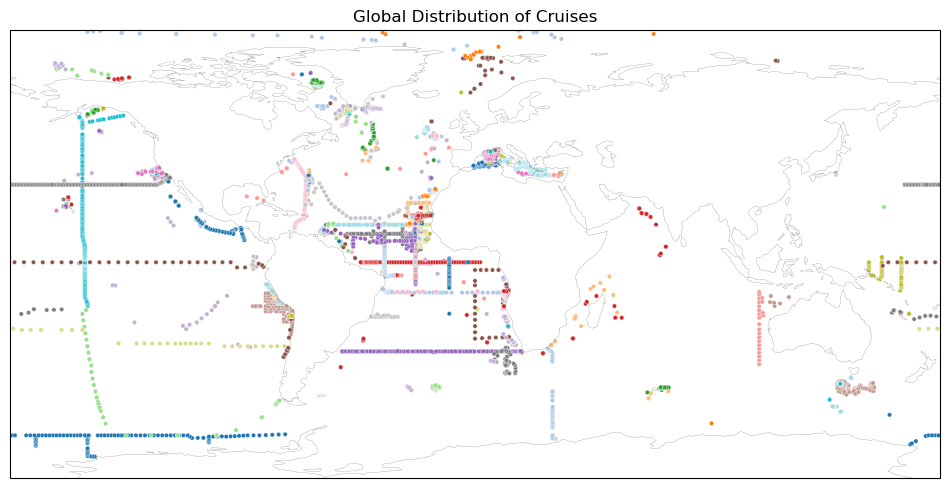

In [69]:
# plot global distribution of Cruises
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
# plot world map as background from cartopy
import cartopy.crs as ccrs
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(color='black', linewidth=0.1)
sns.scatterplot(data=data, x='Longitude', y='Latitude', hue='Cruise', palette='tab20', legend=None, s = 10)
plt.title('Global Distribution of Cruises')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## Train-test split

Total profiles after splitting: 5613; target TEST profiles ≈ 1403
Greedy selection info: {'combined_score': 14895.98, 'n_test': 1441, 'n_cruises_test': 24}
Initially selected 24 cruises for TEST.
All absolute-lat bins already covered by initial selection.
Saved mapping to: ../Data\profile_test_mapping.pkl


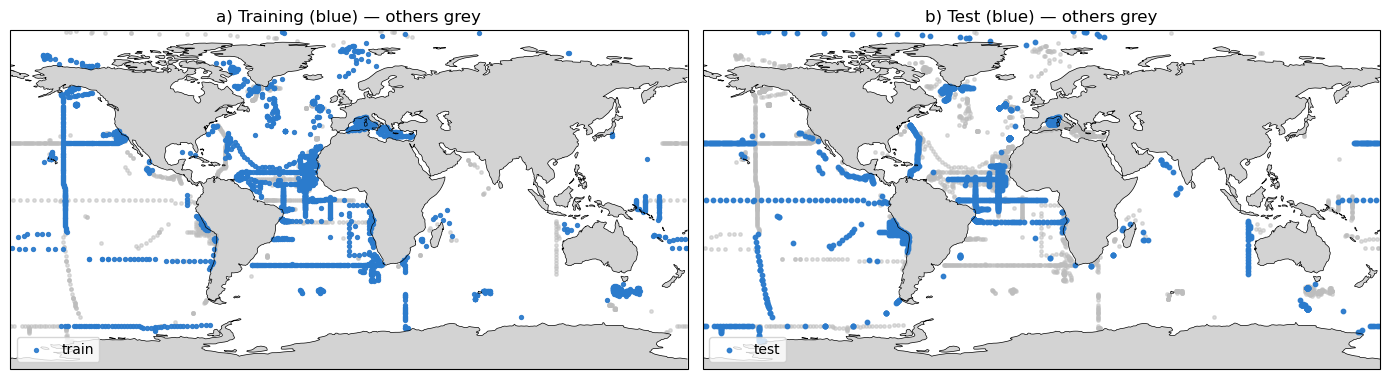


Full cluster counts:
cluster
0     367
1    1072
2     452
3     590
4     319
5     411
6     606
7     259
8     883
9     654
Name: count, dtype: int64

Test cluster counts:
cluster
0    100
1    259
2    117
3    149
4     72
5     90
6    142
7     70
8    270
9    172
Name: count, dtype: int64


In [75]:
"""
Notebook-friendly: select TEST profiles by sampling cruises (with large-cruise splitting),
balancing geographic coverage (absolute-lat bins + lon bins / spatial grid) AND cluster
distribution (target variable). Saves mapping pickle and shows a 2-panel map.

Behavior:
- Uses `data` DataFrame already loaded in the notebook (must contain columns:
  Profile_id, Latitude, Longitude, datetime, Cruise, cluster).
- Splits large cruises (> LARGE_CRUISE_SPLIT_THRESHOLD) into two pseudo-cruises by datetime (…_A / …_B).
- Builds absolute-latitude bins on |Latitude| using LAT_BIN_EDGES.
- Builds longitude bins (LON_BIN_WIDTH) and a combined spatial bin (lat_abs_bin | lon_bin).
- Greedy selection picks (pseudo-)cruises for TEST to:
    * Match cluster frequency in TEST to the full-data cluster distribution (primary if CLUSTER_WEIGHT large),
    * Achieve geographic coverage (lat/lon/spatial) and ensure every absolute-lat bin has >=1 cruise,
    * Respect paired constraint for split cruises (at most one half of a split BaseCruise in TEST),
    * Prefer smaller cruises only as a small secondary preference.
- After greedy selection, ensures every absolute-lat bin has at least one cruise in TEST by adding smallest available cruise covering missing bins.
- Saves a single pickle: ../Data/profile_test_mapping.pkl with columns: Profile_id, data_type ('test' or 'train').
- Shows two-panel inline map:
    a) training in blue, other profiles grey
    b) test in blue, other profiles grey
"""

import os
import random
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional Cartopy for nicer maps; fallback to plain lat/lon scatter if not installed
HAS_CARTOPY = False
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

# ---------------- CONFIG ----------------
RANDOM_SEED = 1
TEST_FRACTION = 0.25                # desired fraction of profiles in TEST (may slightly overshoot)
LAT_BIN_EDGES = [10, 30, 50, 70, 90]  # absolute-latitude edges in degrees (0..90)
LON_BIN_WIDTH = 20.0                # degrees per longitude bin
LARGE_CRUISE_SPLIT_THRESHOLD = 90  # split cruises larger than this into A/B halves
SPLIT_LABEL_A = "_A"
SPLIT_LABEL_B = "_B"
GREEDY_RESTARTS = 200               # number of random restarts for greedy search
CLUSTER_WEIGHT = 3.0                # weight for cluster-distribution mismatch in combined score (increase to prioritize cluster matching)
GEO_WEIGHT = 1.0                    # weight for geographic mismatch
SIZE_PENALTY = 0.001                # tiny penalty per profile to prefer smaller cruises (secondary)
COVERAGE_PENALTY = 60.0             # penalty for missing geographic bins in score
OUT_DIR = "../Data"
OUT_PKL = os.path.join(OUT_DIR, "profile_test_mapping.pkl")
os.makedirs(OUT_DIR, exist_ok=True)
# ----------------------------------------

# Column names in `data` (must exist)
COL_PROFILE = "Profile_id"
COL_LAT = "Latitude"
COL_LON = "Longitude"
COL_DT = "datetime"
COL_CRUISE = "Cruise"
COL_CLUSTER = "cluster"

# ------- helper functions --------

def set_seed(s):
    random.seed(s)
    np.random.seed(s)

def check_input_df():
    if 'data' not in globals():
        raise RuntimeError("Please provide your dataframe as the variable `data` in the notebook.")
    df = globals()['data']
    if not isinstance(df, pd.DataFrame):
        raise RuntimeError("`data` exists but is not a pandas DataFrame.")
    missing = [c for c in [COL_PROFILE, COL_LAT, COL_LON, COL_DT, COL_CRUISE, COL_CLUSTER] if c not in df.columns]
    if missing:
        raise RuntimeError(f"Input dataframe `data` is missing required columns: {missing}")
    return df.copy()

def split_large_cruises(df, threshold):
    """
    Split cruises with > threshold profiles into two pseudo-cruises by datetime.
    Adds 'BaseCruise' linking halves and updates Cruise values to include _A/_B for halves.
    """
    df = df.copy()
    df['BaseCruise'] = df[COL_CRUISE].astype(str)
    sizes = df.groupby(COL_CRUISE).size()
    large = sizes[sizes > threshold].index.tolist()
    for cr in large:
        sub = df[df[COL_CRUISE] == cr]
        if sub[COL_DT].notna().any():
            sub_sorted = sub.sort_values(COL_DT)
        else:
            sub_sorted = sub.sort_index()
        n = len(sub_sorted)
        half = n // 2
        idx_a = sub_sorted.iloc[:half].index
        idx_b = sub_sorted.iloc[half:].index
        df.loc[idx_a, COL_CRUISE] = f"{cr}{SPLIT_LABEL_A}"
        df.loc[idx_b, COL_CRUISE] = f"{cr}{SPLIT_LABEL_B}"
        df.loc[idx_a, 'BaseCruise'] = cr
        df.loc[idx_b, 'BaseCruise'] = cr
    return df

def make_abs_lat_bins(df, edges):
    lat_abs = df[COL_LAT].abs().astype(float)
    edges_sorted = sorted(edges)
    if edges_sorted[0] != 0.0:
        edges_sorted = [0.0] + edges_sorted
    if edges_sorted[-1] < 90.0:
        edges_sorted = edges_sorted + [90.0]
    labels = []
    for i in range(len(edges_sorted)-1):
        labels.append(f"{int(edges_sorted[i])}-{int(edges_sorted[i+1])}")
    bins = pd.cut(lat_abs, bins=edges_sorted, labels=labels, include_lowest=True, right=False)
    return bins.astype(str)

def make_lon_bins(df, width_deg):
    lon = (pd.to_numeric(df[COL_LON], errors='coerce') + 180.0) % 360.0 - 180.0
    edges = np.arange(-180.0, 180.0 + 1e-6, width_deg)
    bins = pd.cut(lon, bins=edges, include_lowest=True, right=False)
    return bins.astype(str)

def summarize_geo(rows):
    return {
        'lat': rows['lat_abs_bin'].value_counts().to_dict(),
        'lon': rows['lon_bin'].value_counts().to_dict(),
        'spatial': rows['spatial_bin'].value_counts().to_dict()
    }

def l1dist(a, b):
    keys = set(a.keys()) | set(b.keys())
    return sum(abs(a.get(k, 0) - b.get(k, 0)) for k in keys)

def coverage_misses(curr, target):
    keys = set(k for k, v in target.items() if v > 0)
    return sum(1 for k in keys if curr.get(k, 0) == 0)

def score_geo(current_counts, target_geo):
    d_lat = l1dist(current_counts['lat'], target_geo['lat'])
    d_lon = l1dist(current_counts['lon'], target_geo['lon'])
    d_sp = l1dist(current_counts['spatial'], target_geo['spatial'])
    c_lat = coverage_misses(current_counts['lat'], target_geo['lat'])
    c_lon = coverage_misses(current_counts['lon'], target_geo['lon'])
    c_sp = coverage_misses(current_counts['spatial'], target_geo['spatial'])
    return GEO_WEIGHT * (d_lat + 0.8 * d_lon + 1.5 * d_sp) + COVERAGE_PENALTY * (c_lat + c_lon + c_sp)

def score_cluster(current_cluster_counts, target_cluster_counts):
    # L1 distance between current and target cluster counts
    return l1dist(current_cluster_counts, target_cluster_counts)

# ------- greedy selection combining geo + cluster -------

def greedy_select_test_balanced(df, test_target_n, restarts=200):
    """
    Greedy selection that combines cluster-distribution matching and geographic coverage.
    At each step, pick cruise that minimizes combined_score = CLUSTER_WEIGHT * cluster_score + GEO_WEIGHT * geo_score + SIZE_PENALTY * size
    Respects paired constraint: at most one half from a split BaseCruise.
    Prefers smaller cruises only as small penalty.
    """
    cruises = df[COL_CRUISE].unique().tolist()
    groups = df.groupby(COL_CRUISE)
    cruise_size = groups.size().to_dict()
    cruise_geo = {c: summarize_geo(groups.get_group(c)) for c in cruises}
    cruise_cluster = {c: groups.get_group(c)[COL_CLUSTER].value_counts().to_dict() for c in cruises}

    # target geo = full dataset geo counts
    target_geo = summarize_geo(df)
    # target cluster counts for TEST: proportional to full distribution scaled to test_target_n
    full_cluster_counts = df[COL_CLUSTER].value_counts().to_dict()
    total_profiles = len(df)
    target_cluster = {k: int(round(v / total_profiles * test_target_n)) for k, v in full_cluster_counts.items()}
    # ensure at least 1 for clusters present overall
    for k, v in full_cluster_counts.items():
        if v > 0 and target_cluster.get(k, 0) == 0:
            target_cluster[k] = 1

    base_map = df.groupby('BaseCruise')[COL_CRUISE].unique().apply(list).to_dict()
    paired_bases = {b for b, lst in base_map.items() if any(s.endswith(SPLIT_LABEL_A) or s.endswith(SPLIT_LABEL_B) for s in lst)}

    best_selection = None
    best_info = None
    best_score = float('inf')

    for _ in range(restarts):
        # candidate order randomized but we'll choose best improvement each iteration
        remaining = set(cruises)
        selected = set()
        base_used = set()
        current_geo = {'lat': defaultdict(int), 'lon': defaultdict(int), 'spatial': defaultdict(int)}
        current_cluster = defaultdict(int)
        current_n = 0

        # Greedy loop: select cruise that gives best combined improvement
        while current_n < test_target_n and remaining:
            best_c = None
            best_comb = float('inf')
            # evaluate each remaining candidate (respect paired constraint)
            for c in list(remaining):
                base = df.loc[df[COL_CRUISE] == c, 'BaseCruise'].iat[0]
                if base in base_used and (c.endswith(SPLIT_LABEL_A) or c.endswith(SPLIT_LABEL_B)):
                    continue
                # trial aggregated counts
                trial_geo = {
                    'lat': dict(current_geo['lat']),
                    'lon': dict(current_geo['lon']),
                    'spatial': dict(current_geo['spatial'])
                }
                for k,v in cruise_geo[c]['lat'].items(): trial_geo['lat'][k] = trial_geo['lat'].get(k,0) + v
                for k,v in cruise_geo[c]['lon'].items(): trial_geo['lon'][k] = trial_geo['lon'].get(k,0) + v
                for k,v in cruise_geo[c]['spatial'].items(): trial_geo['spatial'][k] = trial_geo['spatial'].get(k,0) + v
                geo_score = score_geo(trial_geo, target_geo)

                trial_cluster = dict(current_cluster)
                for k,v in cruise_cluster[c].items(): trial_cluster[k] = trial_cluster.get(k,0) + v
                cluster_score = score_cluster(trial_cluster, target_cluster)

                combined = CLUSTER_WEIGHT * cluster_score + GEO_WEIGHT * geo_score + SIZE_PENALTY * cruise_size.get(c,0)

                if combined < best_comb:
                    best_comb = combined
                    best_c = c

            if best_c is None:
                break  # no allowed candidate
            # accept best_c
            selected.add(best_c)
            base = df.loc[df[COL_CRUISE] == best_c, 'BaseCruise'].iat[0]
            if base in paired_bases:
                base_used.add(base)
            # update current counts
            for k,v in cruise_geo[best_c]['lat'].items(): current_geo['lat'][k] += v
            for k,v in cruise_geo[best_c]['lon'].items(): current_geo['lon'][k] += v
            for k,v in cruise_geo[best_c]['spatial'].items(): current_geo['spatial'][k] += v
            for k,v in cruise_cluster[best_c].items(): current_cluster[k] += v
            current_n += cruise_size.get(best_c,0)
            remaining.remove(best_c)

        # if still short, add smallest allowed cruises until target
        if current_n < test_target_n:
            remaining_sorted = sorted(list(remaining), key=lambda c: cruise_size.get(c,0))
            for c in remaining_sorted:
                base = df.loc[df[COL_CRUISE] == c, 'BaseCruise'].iat[0]
                if base in base_used and (c.endswith(SPLIT_LABEL_A) or c.endswith(SPLIT_LABEL_B)):
                    continue
                selected.add(c)
                if base in paired_bases:
                    base_used.add(base)
                for k,v in cruise_geo[c]['lat'].items(): current_geo['lat'][k] += v
                for k,v in cruise_geo[c]['lon'].items(): current_geo['lon'][k] += v
                for k,v in cruise_geo[c]['spatial'].items(): current_geo['spatial'][k] += v
                for k,v in cruise_cluster[c].items(): current_cluster[k] += v
                current_n += cruise_size.get(c,0)
                if current_n >= test_target_n:
                    break

        # compute final combined score for this restart
        final_geo = score_geo(current_geo, target_geo)
        final_cluster = score_cluster(current_cluster, target_cluster)
        final_combined = CLUSTER_WEIGHT * final_cluster + GEO_WEIGHT * final_geo + 0.01 * abs(current_n - test_target_n)

        if final_combined < best_score:
            best_score = final_combined
            best_selection = list(selected)
            best_info = {'combined_score': final_combined, 'n_test': current_n, 'n_cruises_test': len(selected)}

    return best_selection, best_info, target_cluster, target_geo

# ------- ensure coverage of lat bins -------

def ensure_each_lat_bin(df, selected_cruises):
    groups = df.groupby(COL_CRUISE)
    cruise_size = groups.size().to_dict()

    sel_df = df[df[COL_CRUISE].isin(selected_cruises)]
    sel_bins = set(sel_df['lat_abs_bin'].unique())
    all_bins = set(df['lat_abs_bin'].unique())

    base_map = df.groupby('BaseCruise')[COL_CRUISE].unique().apply(list).to_dict()
    paired_bases = {b for b,lst in base_map.items() if any(s.endswith(SPLIT_LABEL_A) or s.endswith(SPLIT_LABEL_B) for s in lst)}
    used_bases = set(df.loc[df[COL_CRUISE].isin(selected_cruises), 'BaseCruise'].unique())

    missing = sorted(list(all_bins - sel_bins))
    added = []
    for b in missing:
        candidates = []
        for c, grp in groups:
            if c in selected_cruises:
                continue
            base = df.loc[df[COL_CRUISE] == c, 'BaseCruise'].iat[0]
            if base in used_bases and (c.endswith(SPLIT_LABEL_A) or c.endswith(SPLIT_LABEL_B)):
                continue
            if (grp['lat_abs_bin'] == b).any():
                candidates.append(c)
        if not candidates:
            continue
        candidates.sort(key=lambda x: cruise_size.get(x, 1))
        pick = candidates[0]
        selected_cruises.append(pick)
        added.append(pick)
        used_bases.add(df.loc[df[COL_CRUISE] == pick, 'BaseCruise'].iat[0])
    return selected_cruises, added

# ------- plotting -------

def plot_two_panel(df, mapping):
    merged = df[[COL_PROFILE, COL_LAT, COL_LON, COL_CRUISE]].merge(mapping, on=COL_PROFILE, how='left')
    merged[COL_LAT] = pd.to_numeric(merged[COL_LAT], errors='coerce')
    merged[COL_LON] = pd.to_numeric(merged[COL_LON], errors='coerce')
    merged = merged.dropna(subset=[COL_LAT, COL_LON])

    train = merged[merged['data_type'] != 'test']  # train = everything else
    test = merged[merged['data_type'] == 'test']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                             subplot_kw={'projection': ccrs.PlateCarree()} if HAS_CARTOPY else {})
    # Panel A: training blue, others grey
    ax = axes[0]
    if HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5); ax.add_feature(cfeature.LAND, facecolor='lightgray'); ax.set_global()
        ax.scatter(merged[COL_LON], merged[COL_LAT], s=6, c='#bdbdbd', alpha=0.5, transform=ccrs.PlateCarree())
        ax.scatter(train[COL_LON], train[COL_LAT], s=8, c='#2b7bcd', alpha=0.9, transform=ccrs.PlateCarree(), label='train')
    else:
        ax.set_facecolor('lightgray')
        ax.scatter(merged[COL_LON], merged[COL_LAT], s=6, c='#bdbdbd', alpha=0.5)
        ax.scatter(train[COL_LON], train[COL_LAT], s=8, c='#2b7bcd', alpha=0.9, label='train')
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title("a) Training (blue) — others grey")
    ax.legend(loc='lower left')

    # Panel B: test blue, others grey
    ax = axes[1]
    if HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5); ax.add_feature(cfeature.LAND, facecolor='lightgray'); ax.set_global()
        ax.scatter(merged[COL_LON], merged[COL_LAT], s=6, c='#bdbdbd', alpha=0.5, transform=ccrs.PlateCarree())
        ax.scatter(test[COL_LON], test[COL_LAT], s=10, c='#2b7bcd', alpha=0.95, transform=ccrs.PlateCarree(), label='test')
    else:
        ax.set_facecolor('lightgray')
        ax.scatter(merged[COL_LON], merged[COL_LAT], s=6, c='#bdbdbd', alpha=0.5)
        ax.scatter(test[COL_LON], test[COL_LAT], s=10, c='#2b7bcd', alpha=0.95, label='test')
        ax.set_xlim(-180, 180); ax.set_ylim(-90, 90); ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title("b) Test (blue) — others grey")
    ax.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

# ------- main -------

def main():
    set_seed(RANDOM_SEED)
    df0 = check_input_df()

    # split large cruises -> pseudo-cruises
    df = split_large_cruises(df0, LARGE_CRUISE_SPLIT_THRESHOLD)

    # create absolute-latitude bins (on |Latitude|)
    df['lat_abs_bin'] = make_abs_lat_bins(df, LAT_BIN_EDGES)
    df['lon_bin'] = make_lon_bins(df, LON_BIN_WIDTH)
    df['spatial_bin'] = df['lat_abs_bin'].astype(str) + " | " + df['lon_bin'].astype(str)

    total = len(df)
    test_target = int(round(TEST_FRACTION * total))
    print(f"Total profiles after splitting: {total}; target TEST profiles ≈ {test_target}")

    # greedy selection balancing clusters and geography
    selected_cruises, info, target_cluster, target_geo = greedy_select_test_balanced(df, test_target, restarts=GREEDY_RESTARTS)
    print("Greedy selection info:", info)
    print(f"Initially selected {len(selected_cruises)} cruises for TEST.")

    # ensure each absolute-lat bin has at least one cruise in TEST
    selected_cruises, added = ensure_each_lat_bin(df, selected_cruises)
    if added:
        print(f"Added {len(added)} cruises to cover missing absolute-lat bins: {added}")
    else:
        print("All absolute-lat bins already covered by initial selection.")

    # assign mapping Profile_id -> data_type
    df['data_type'] = df[COL_CRUISE].isin(selected_cruises).map({True: 'test', False: 'train'})
    mapping = df[[COL_PROFILE, 'data_type']].copy()

    # Save mapping pickle
    mapping.to_pickle(OUT_PKL)
    print("Saved mapping to:", OUT_PKL)

    # show maps inline
    plot_two_panel(df, mapping)

    # diagnostic: print cluster counts full vs test
    full_cluster = df[COL_CLUSTER].value_counts().sort_index()
    test_cluster = df[df['data_type']=='test'][COL_CLUSTER].value_counts().sort_index()
    print("\nFull cluster counts:")
    print(full_cluster)
    print("\nTest cluster counts:")
    print(test_cluster)
    return mapping, selected_cruises

if __name__ == "__main__":
    mapping_df, selected_test_cruises = main()

In [78]:

mapped = pd.read_pickle('../Data/profile_test_mapping.pkl')
merged = mapped.merge(data, on="Profile_id", how='left')
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5613 entries, 0 to 5612
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Profile_id    5613 non-null   object        
 1   data_type     5613 non-null   object        
 2   Latitude      5613 non-null   float64       
 3   Longitude     5613 non-null   float64       
 4   datetime      5613 non-null   datetime64[ns]
 5   Cruise        5613 non-null   object        
 6   MarineRegion  5613 non-null   object        
 7   cluster       5613 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(1), object(4)
memory usage: 329.0+ KB


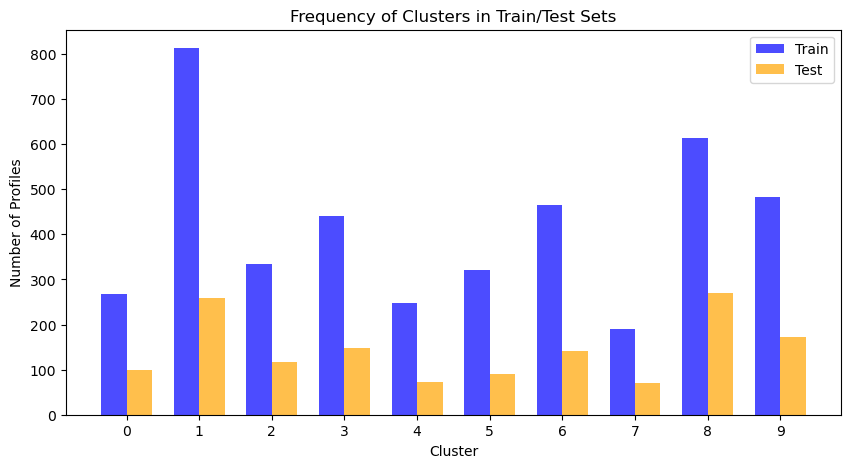

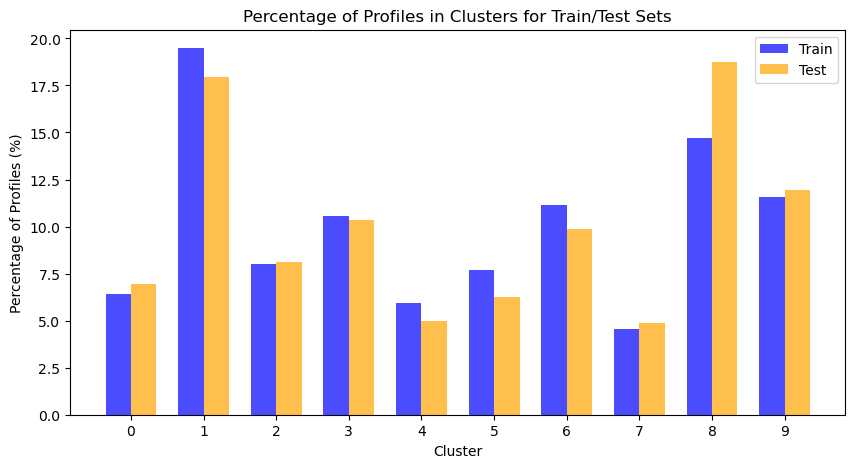

In [79]:
merged_clusters = merged.copy()

# plot frequency of clusters in train/test
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
train_clusters = merged_clusters[merged_clusters['data_type'] != 'test']['cluster'].value_counts().sort_index()
test_clusters = merged_clusters[merged_clusters['data_type'] == 'test']['cluster'].value_counts().sort_index()
width = 0.35
plt.bar(train_clusters.index - width/2, train_clusters.values, width=width, label='Train', color='blue', alpha=0.7)
plt.bar(test_clusters.index + width/2, test_clusters.values, width=width, label='Test', color='orange', alpha=0.7)
plt.xlabel('Cluster')
plt.ylabel('Number of Profiles')
plt.title('Frequency of Clusters in Train/Test Sets')
plt.xticks(train_clusters.index)
plt.legend()
plt.show()

# plot the percent of profiles in train and test set that are in each cluster
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
total_profiles_train = len(merged_clusters[merged_clusters['data_type'] != 'test'])
total_profiles_test = len(merged_clusters[merged_clusters['data_type'] == 'test'])

train_percent = merged_clusters[merged_clusters['data_type'] != 'test']['cluster'].value_counts().sort_index() / total_profiles_train * 100
test_percent = merged_clusters[merged_clusters['data_type'] == 'test']['cluster'].value_counts().sort_index() / total_profiles_test * 100
width = 0.35
plt.bar(train_percent.index - width/2, train_percent.values, width=width, label='Train', color='blue', alpha=0.7)
plt.bar(test_percent.index + width/2, test_percent.values, width=width, label='Test', color='orange', alpha=0.7)
plt.xlabel('Cluster')
plt.ylabel('Percentage of Profiles (%)')
plt.title('Percentage of Profiles in Clusters for Train/Test Sets')
plt.xticks(train_percent.index)
plt.legend()
plt.show()


## Validation folds

No cruises exceed the threshold; no splitting applied.
Training cruises after splitting: 187 requested folds: 4
Fold profile loads: [1043, 1043, 1043, 1043]
Fold 1 cruise count: 46
Fold 2 cruise count: 47
Fold 3 cruise count: 47
Fold 4 cruise count: 47
Saved mapping to: ../Data\Profile_id_to_train_test_cross_val.pkl


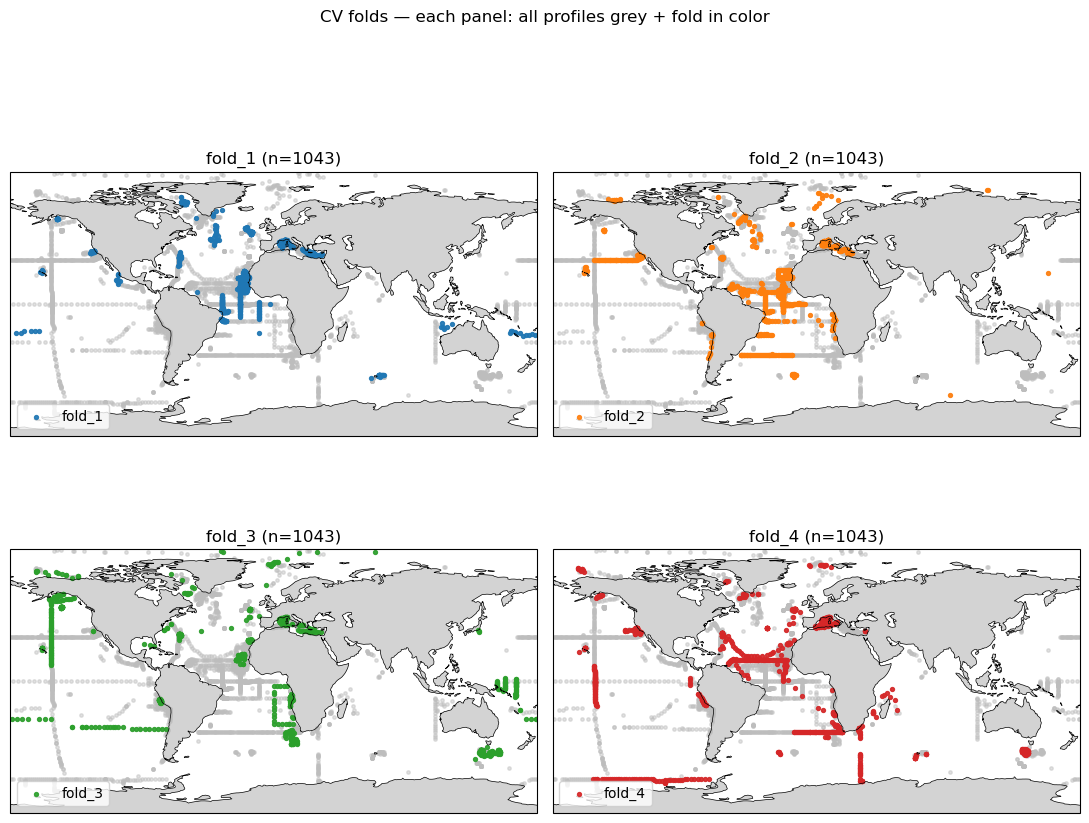

Done — merged['CV_fold'] updated. Mapping saved to: ../Data\Profile_id_to_train_test_cross_val.pkl


In [95]:
"""
Notebook-friendly: split large cruises by datetime into two equally-sized pseudo-cruises,
then assign training cruises to CV folds using a balanced round-robin (largest-first -> assign
to fold with smallest current load) to ensure roughly equal profile counts across folds.

Inputs:
- `merged` DataFrame already loaded in the notebook. Must contain columns:
  ['Profile_id','Latitude','Longitude','datetime','Cruise','data_type', 'MarineRegion' (optional)]

Outputs:
- Adds/overwrites merged['CV_fold'] with 'fold_1'..'fold_K' for training rows and '' for test rows.
- Saves mapping pickle to ../Data/profile_train_cv_mapping_equal.pkl with columns [Profile_id, data_type, CV_fold].
- Displays multi-panel map: one panel per fold (all points grey, fold in color).

Adjust parameters in the CONFIG block below.
"""
import os
import random
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional cartopy for nicer maps
HAS_CARTOPY = False
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

# ============== CONFIG ==============
RANDOM_SEED = 2025
N_CV_FOLDS = 4
LARGE_CRUISE_SPLIT_THRESHOLD = 100   # cruises with > this many profiles will be split
SPLIT_SUFFIX_A = "_A"
SPLIT_SUFFIX_B = "_B"

LAT_BIN_EDGES = [0,10,20,30,40,50,60,90]  # optional: used only for plotting/diagnostics if desired
LON_BIN_WIDTH = 20.0

OUT_DIR = "../Data"
OUT_PKL = os.path.join(OUT_DIR, "Profile_id_to_train_test_cross_val.pkl")
SAVE_MAPPING = True
# ====================================

def set_seed(s):
    random.seed(s)
    np.random.seed(s)

def require_merged():
    if 'merged' not in globals() or not isinstance(globals()['merged'], pd.DataFrame):
        raise RuntimeError("Please load your table into the notebook variable `merged` before running this cell.")
    return globals()['merged']

def split_large_cruises_equal(df, threshold):
    """
    For cruises with size > threshold: split into two pseudo-cruises by datetime order,
    making the halves as equal in count as possible. Returns a new DataFrame copy and
    a list of all new cruise ids created.
    """
    df = df.copy()
    # ensure datetime dtype
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df['BaseCruise'] = df['Cruise'].astype(str)

    cruise_sizes = df.groupby('Cruise').size()
    large_cruises = cruise_sizes[cruise_sizes > threshold].index.tolist()

    if not large_cruises:
        print("No cruises exceed the threshold; no splitting applied.")
        return df

    for cr in large_cruises:
        mask = df['Cruise'] == cr
        subset = df.loc[mask].copy()
        # sort by datetime if available, otherwise by index
        if subset['datetime'].notna().any():
            subset = subset.sort_values('datetime')
        else:
            subset = subset.sort_index()
        n = len(subset)
        half = n // 2
        idx_a = subset.iloc[:half].index
        idx_b = subset.iloc[half:].index
        new_a = f"{cr}{SPLIT_SUFFIX_A}"
        new_b = f"{cr}{SPLIT_SUFFIX_B}"
        df.loc[idx_a, 'Cruise'] = new_a
        df.loc[idx_b, 'Cruise'] = new_b
        # maintain BaseCruise linking for reference
        df.loc[idx_a, 'BaseCruise'] = cr
        df.loc[idx_b, 'BaseCruise'] = cr
        print(f"Split cruise {cr} -> {new_a} ({len(idx_a)}) and {new_b} ({len(idx_b)})")
    return df

def assign_folds_roundrobin_by_load(df_train, n_folds, seed=RANDOM_SEED):
    """
    Assign each cruise (whole) to one of n_folds attempting to equalize profile counts.
    Strategy: sort cruises by size descending, assign each cruise to the fold with smallest current load.
    Returns mapping cruise_id -> fold_index (0..n_folds-1) and fold loads.
    """
    cruise_sizes = df_train.groupby('Cruise').size().to_dict()
    cruises = sorted(cruise_sizes.keys(), key=lambda c: cruise_sizes[c], reverse=True)
    fold_loads = [0]*n_folds
    fold_cruises = [list() for _ in range(n_folds)]
    cruise_to_fold = {}

    for c in cruises:
        # choose fold with smallest current load
        idx = int(np.argmin(fold_loads))
        cruise_to_fold[c] = idx
        fold_cruises[idx].append(c)
        fold_loads[idx] += cruise_sizes[c]
    return cruise_to_fold, fold_loads, fold_cruises

def map_and_save(merged_df, cruise_to_fold, out_pkl=OUT_PKL, save_mapping=SAVE_MAPPING):
    df = merged_df.copy()
    # initialize CV_fold
    df['CV_fold'] = ''
    # assign for train rows
    train_mask = df['data_type']=='train'
    # Some cruises might not be in mapping (shouldn't), treat them as fallback: assign to least-loaded fold if needed
    for cruise, fold_idx in cruise_to_fold.items():
        mask = (df['Cruise'] == cruise) & (df['data_type'] == 'train')
        df.loc[mask, 'CV_fold'] = f"fold_{int(fold_idx)+1}"
    # If any train rows left unassigned, assign them to least loaded fold (safety)
    unassigned = df[train_mask & (df['CV_fold']=='')].shape[0]
    if unassigned > 0:
        print(f"Warning: {unassigned} training profiles had cruises not in cruise->fold map; assigning to least-loaded fold.")
        # compute current fold sizes
        counts = df[df['CV_fold']!=''].groupby('CV_fold').size().to_dict()
        # choose fold with minimum
        minfold = min([f"fold_{i+1}" for i in range(N_CV_FOLDS)], key=lambda x: counts.get(x,0))
        df.loc[train_mask & (df['CV_fold']==''), 'CV_fold'] = minfold

    # test rows keep CV_fold empty
    df.loc[df['data_type']!='train', 'CV_fold'] = ''
    # Save mapping
    mapping = df[['Profile_id','data_type','CV_fold']].copy()
    if save_mapping:
        os.makedirs(os.path.dirname(out_pkl), exist_ok=True)
        mapping.to_pickle(out_pkl)
        print("Saved mapping to:", out_pkl)
    return df, mapping

def plot_fold_panels(df_with_folds, n_folds):
    palette = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']
    folds = [f"fold_{i+1}" for i in range(n_folds)]
    ncols = min(2, n_folds)
    nrows = int(np.ceil(n_folds / ncols))
    figsize = (5.5 * ncols, 4.5 * nrows)
    if HAS_CARTOPY:
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
    else:
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    lon_all = df_with_folds['Longitude'].to_numpy()
    lat_all = df_with_folds['Latitude'].to_numpy()

    for i, fold in enumerate(folds):
        ax = axes[i]
        if HAS_CARTOPY:
            ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
            ax.add_feature(cfeature.LAND, facecolor='lightgray')
            ax.set_global()
            ax.scatter(lon_all, lat_all, s=6, c='#bdbdbd', alpha=0.45, transform=ccrs.PlateCarree())
            sub = df_with_folds[df_with_folds['CV_fold']==fold]
            ax.scatter(sub['Longitude'], sub['Latitude'], s=8, c=palette[i%len(palette)], alpha=0.9, transform=ccrs.PlateCarree(), label=fold)
        else:
            ax.set_facecolor('lightgray')
            ax.scatter(lon_all, lat_all, s=6, c='#bdbdbd', alpha=0.45)
            sub = df_with_folds[df_with_folds['CV_fold']==fold]
            ax.scatter(sub['Longitude'], sub['Latitude'], s=8, c=palette[i%len(palette)], alpha=0.9, label=fold)
            ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
            ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        ax.set_title(f"{fold} (n={len(sub)})")
        ax.legend(loc='lower left', frameon=True)

    # hide extra axes if any
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.suptitle("CV folds — each panel: all profiles grey + fold in color", y=1.02)
    plt.tight_layout()
    plt.show()

# ----------------- run the process -----------------
set_seed(RANDOM_SEED)
merged_df = require_merged()

# 1) split large cruises by datetime into equal halves
merged_split = split_large_cruises_equal(merged_df, LARGE_CRUISE_SPLIT_THRESHOLD)

# 2) optionally compute lat/lon bins (not required for round-robin)
# (kept for diagnostics; not used in assignment)
merged_split['lat_abs_bin'] = merged_split['Latitude'].abs().pipe(lambda s: pd.cut(s, bins=[0,10,20,30,40,50,60,90], include_lowest=True)).astype(str)
lon = (pd.to_numeric(merged_split['Longitude'], errors='coerce') + 180.0) % 360.0 - 180.0
merged_split['lon_bin'] = pd.cut(lon, bins=np.arange(-180,180+1e-6,LON_BIN_WIDTH), include_lowest=True, right=False).astype(str)
merged_split['spatial_bin'] = merged_split['lat_abs_bin'].astype(str) + " | " + merged_split['lon_bin'].astype(str)

# 3) subset training cruises and assign folds by balanced round-robin
df_train = merged_split[merged_split['data_type']=='train'].copy()
n_train_cruises = df_train['Cruise'].nunique()
print("Training cruises after splitting:", n_train_cruises, "requested folds:", N_CV_FOLDS)
if n_train_cruises < N_CV_FOLDS:
    print(f"Warning: only {n_train_cruises} training cruises available; reducing folds to {n_train_cruises}")
    n_folds_use = n_train_cruises
else:
    n_folds_use = N_CV_FOLDS

cruise_to_fold_map, fold_loads, fold_cruises = assign_folds_roundrobin_by_load(df_train, n_folds_use)
print("Fold profile loads:", fold_loads)
for i, lst in enumerate(fold_cruises):
    print(f"Fold {i+1} cruise count: {len(lst)}")

# 4) map back and save
merged_with_folds, mapping = map_and_save(merged_split, cruise_to_fold_map, out_pkl=OUT_PKL, save_mapping=SAVE_MAPPING)

# 5) diagnostics and plot multi-panel map
plot_fold_panels(merged_with_folds, n_folds_use)

# 6) update notebook variable
merged = merged_with_folds
print("Done — merged['CV_fold'] updated. Mapping saved to:", OUT_PKL if SAVE_MAPPING else "not saved")

In [88]:
df = pd.read_pickle('../Data/Profile_id_to_train_test_cross_val.pkl')
df.head(40)

,Profile_id,data_type,CV_fold
0,s033,test,
1,s035,test,
2,s034,test,
3,s036,test,
4,s037,test,
5,s038,test,
6,s039,test,
7,s040,test,
8,s041,test,
9,s042,test,


In [90]:
# percent of profiles in each fold and data_type
total_profiles = len(df)
fold_counts = df[df['data_type']=='train']['CV_fold'].value_counts().sort_index()
test_count = len(df[df['data_type']=='test'])
print(f"Total profiles: {total_profiles}")
print(f"Training profiles: {total_profiles - test_count}")
print("Training fold counts and percentages:")
for fold, count in fold_counts.items():
    percent = (count / total_profiles) * 100
    print(f"{fold}: {count} profiles ({percent:.2f}%)")
print(f"\nTest set: {test_count} profiles ({(test_count / total_profiles) * 100:.2f}%)")

Total profiles: 5613
Training profiles: 4172
Training fold counts and percentages:
fold_1: 1043 profiles (18.58%)
fold_2: 1043 profiles (18.58%)
fold_3: 1043 profiles (18.58%)
fold_4: 1043 profiles (18.58%)

Test set: 1441 profiles (25.67%)


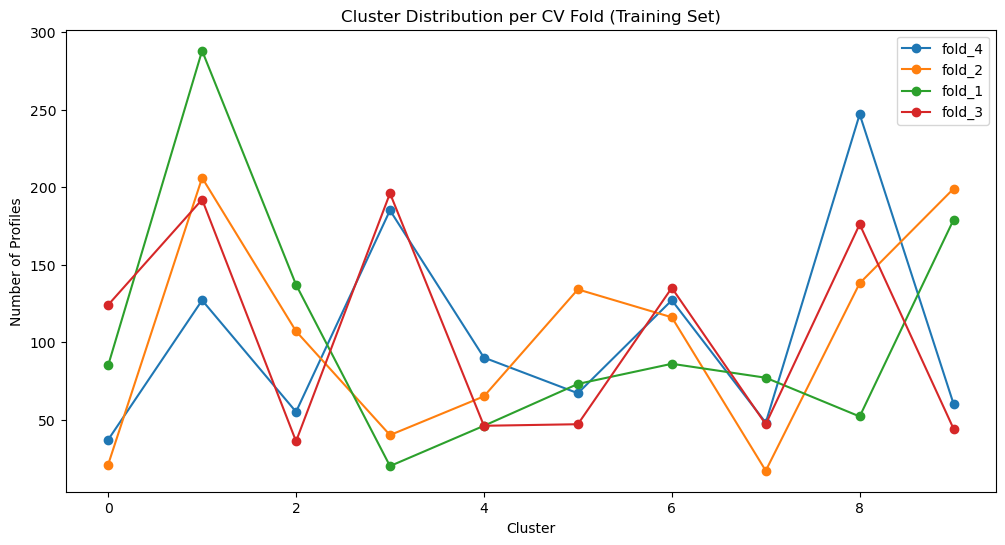

In [96]:
# merge df with data to get cluster info
merged_clusters = df.merge(data[['Profile_id','cluster']], on='Profile_id', how='left')

# how is the distribution of profiles across clusters per fold (train only), bar plot
import matplotlib.pyplot as plt
train_df = merged_clusters[merged_clusters['data_type']=='train']
folds = train_df['CV_fold'].unique().tolist()
plt.figure(figsize=(12,6))
for fold in folds:
    sub = train_df[train_df['CV_fold']==fold]
    cluster_counts = sub['cluster'].value_counts().sort_index()
    plt.plot(cluster_counts.index, cluster_counts.values, marker='o', label=fold)
plt.xlabel('Cluster')
plt.ylabel('Number of Profiles')
plt.title('Cluster Distribution per CV Fold (Training Set)')
plt.legend()
plt.show()